In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import bambi as bmb

warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
bikes = pd.read_csv('../code/data/bikes.csv')
bikes

,rented,hour,temperature,humidity,windspeed,weekday
0,16,0,3.28,0.81,0.0000,6
1,3,5,-0.48,0.47,0.2836,1
2,115,9,2.34,0.37,0.3284,3
3,73,13,1.40,0.37,0.2836,5
4,82,15,2.34,0.35,0.3582,0
...,...,...,...,...,...,...
343,90,9,4.22,0.48,0.3881,6
344,135,12,5.16,0.56,0.0896,1
345,13,15,4.22,0.87,0.3582,3
346,271,17,3.28,0.60,0.1343,5


polynomial

In [3]:
model_poly_1 = bmb.Model('rented ~ hour', bikes, family='negativebinomial')
idata_poly_1 = model_poly_1.fit()
display(idata_poly_1)
model_poly_1

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rented_alpha, Intercept, hour]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

       Formula: rented ~ hour
        Family: negativebinomial
          Link: mu = log
  Observations: 348
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 4.8549)
            hour ~ Normal(mu: 0.0, sigma: 0.3615)
        
        Auxiliary parameters
            alpha ~ HalfCauchy(beta: 1.0)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

In [4]:
model_poly_4 = bmb.Model('rented ~ poly(hour, degree=4)', bikes, family='negativebinomial')
idata_poly_4 = model_poly_4.fit()
display(model_poly_4)
idata_poly_4

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rented_alpha, Intercept, poly(hour, degree=4)]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


       Formula: rented ~ poly(hour, degree=4)
        Family: negativebinomial
          Link: mu = log
  Observations: 348
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 2.5)
            poly(hour, degree=4) ~ Normal(mu: [0. 0. 0. 0.], sigma: [46.6369 46.6369 46.6369 46.6369])
        
        Auxiliary parameters
            alpha ~ HalfCauchy(beta: 1.0)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

Text(0, 0.5, '')

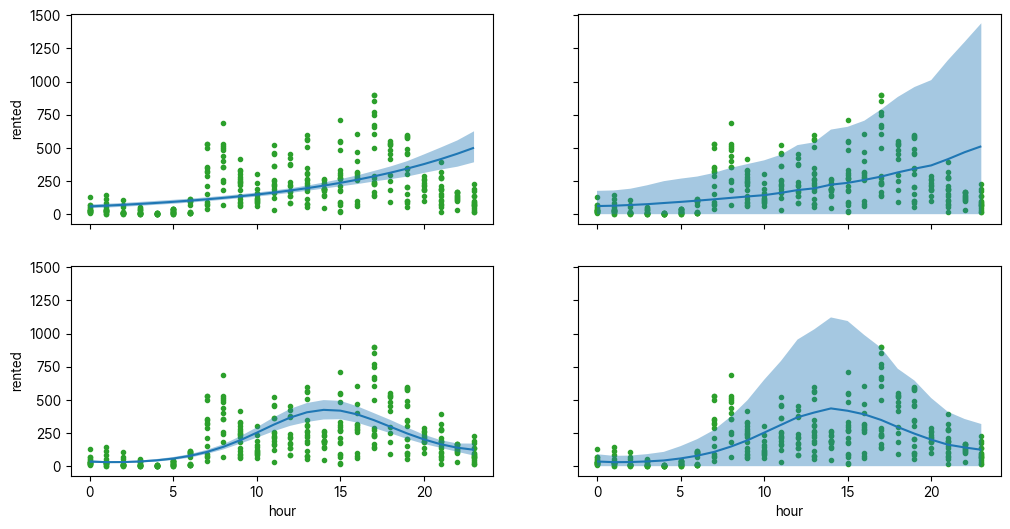

In [5]:
_, axes = plt.subplots(2, 2, sharey=True, sharex='col', figsize=(12, 6))
bmb.interpret.plot_predictions(model_poly_1, idata_poly_1, 'hour', ax=axes[0, 0])
bmb.interpret.plot_predictions(model_poly_1, idata_poly_1, 'hour', pps=True, ax=axes[0, 1])
bmb.interpret.plot_predictions(model_poly_4, idata_poly_4, 'hour', ax=axes[1, 0])
bmb.interpret.plot_predictions(model_poly_4, idata_poly_4, 'hour', pps=True, ax=axes[1, 1])

for ax in axes.ravel():
    ax.plot(bikes.hour, bikes.rented, "C2.", zorder=-3)
axes[0, 0].set_xlabel("")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("")
axes[1, 1].set_ylabel("")


Splines

In [6]:
num_knots = 6
knots = np.linspace(0, 23, num_knots+2)[1:-1]
knots

array([ 3.28571429,  6.57142857,  9.85714286, 13.14285714, 16.42857143,
       19.71428571])

In [7]:
knots = np.quantile(bikes.hour, np.linspace(0, 1, 5))[1:-1]
knots

array([ 5.75, 12.  , 17.  ])

In [8]:
np.unique(knots, return_counts=True)

(array([ 5.75, 12.  , 17.  ]), array([1, 1, 1]))

In [9]:
model_spline = bmb.Model('rented ~ bs(hour, degree=3, knots=knots)', bikes,
                         family='negativebinomial')
idata_spline = model_spline.fit()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rented_alpha, Intercept, bs(hour, degree=3, knots=knots)]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


In [10]:
model_spline

       Formula: rented ~ bs(hour, degree=3, knots=knots)
        Family: negativebinomial
          Link: mu = log
  Observations: 348
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 5.1432)
            bs(hour, degree=3, knots=knots) ~ Normal(mu: [0. 0. 0. 0. 0. 0.], sigma: [12.5485 11.811
                10.4103 11.4426 13.1511 10.6673])
        
        
        Auxiliary parameters
            alpha ~ HalfCauchy(beta: 1.0)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

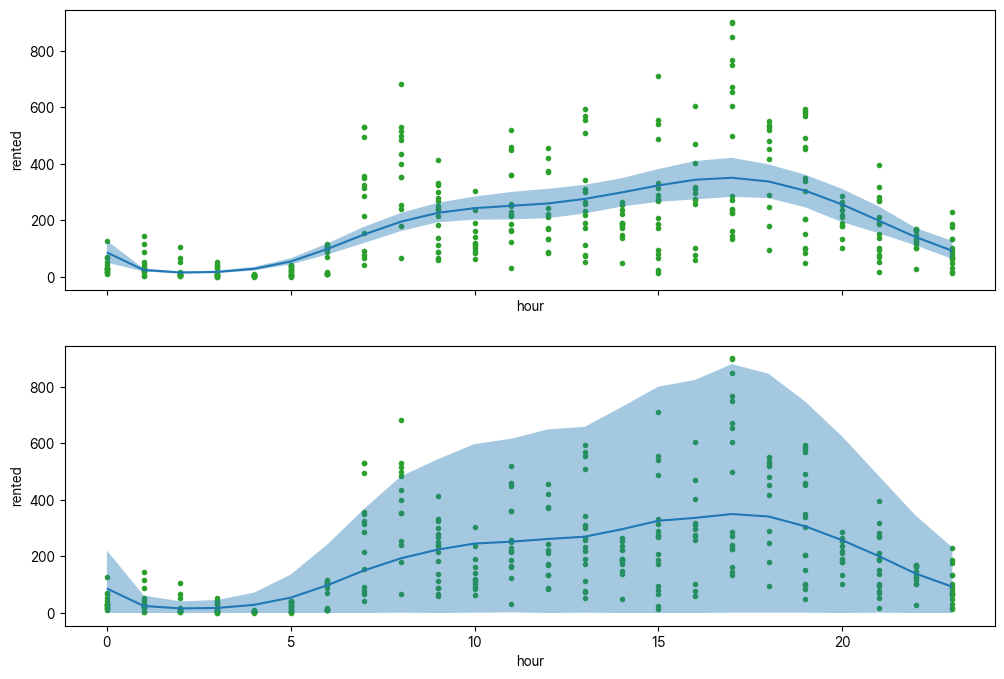

In [11]:
_, ax = plt.subplots(2 ,1, sharey=True, sharex='col', figsize=(12, 8))
bmb.interpret.plot_predictions(model_spline, idata_spline, 'hour', ax=ax[0])
ax[0].plot(bikes.hour, bikes.rented, "C2.", zorder=-3)
bmb.interpret.plot_predictions(model_spline, idata_spline, 'hour', pps=True, ax=ax[1])
ax[1].plot(bikes.hour, bikes.rented, "C2.", zorder=-3)


array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'Intercept'}>],
       [<Axes: title={'center': 'bs(hour, degree=3, knots=knots)'}>,
        <Axes: title={'center': 'bs(hour, degree=3, knots=knots)'}>],
       [<Axes: title={'center': 'rented_alpha'}>,
        <Axes: title={'center': 'rented_alpha'}>]], dtype=object)

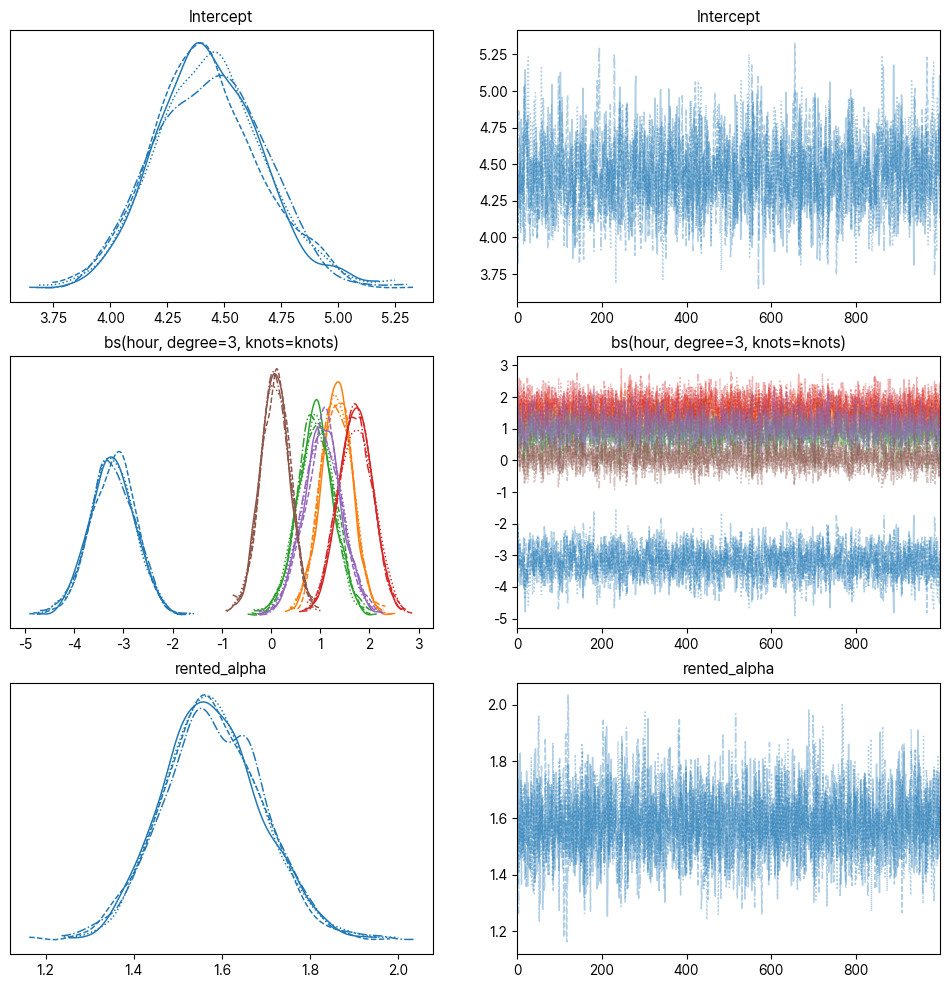

In [12]:
az.plot_trace(idata_spline, figsize=(12, 12))

Distributional models

In [13]:
babies = pd.read_csv('../code/data/babies.csv')
babies

,month,length
0,0,49.192857
1,0,51.221429
2,0,51.221429
3,0,52.742857
4,0,48.178571
...,...,...
791,24,83.645177
792,24,81.135569
793,24,90.929186
794,24,97.351140


In [14]:
formula = bmb.Formula(
    'length ~ np.sqrt(month)',
    'sigma ~ month'
)
model_dis = bmb.Model(formula, babies)
idata_dis = model_dis.fit()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, np.sqrt(month), sigma_Intercept, sigma_month]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [15]:
model_dis

       Formula: length ~ np.sqrt(month)
                sigma ~ month
        Family: gaussian
          Link: mu = identity
                sigma = log
  Observations: 796
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 72.5125, sigma: 72.0827)
            np.sqrt(month) ~ Normal(mu: 0.0, sigma: 21.3849)
    target = sigma
        Common-level effects
            sigma_Intercept ~ Normal(mu: 0.0, sigma: 1.0)
            sigma_month ~ Normal(mu: 0.0, sigma: 1.0)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

In [16]:
idata_dis

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [17]:
model_con = bmb.Model('length ~ np.sqrt(month)', babies)
idata_con = model_con.fit(random_seed=123)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [length_sigma, Intercept, np.sqrt(month)]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


[Text(0.5, 0, 'Alpha posterior'), Text(0, 0.5, 'Density')]

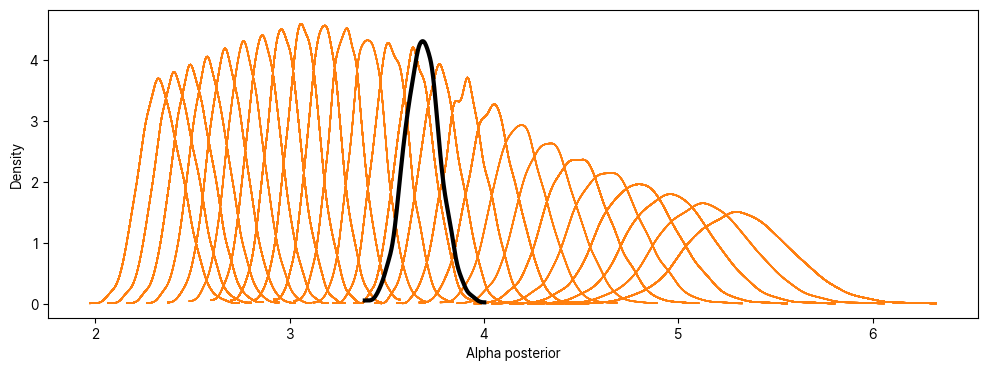

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))
from matplotlib.lines import Line2D

for idx in idata_dis.posterior.coords.get('length_obs'):
    values = idata_dis.posterior['sigma'].sel(length_obs=idx).to_numpy().flatten()
    grid, pdf = az.kde(values)
    ax.plot(grid, pdf, lw=1, color="C1")

values = idata_con.posterior['length_sigma'].to_numpy().flatten()
grid, pdf = az.kde(values)
ax.plot(grid, pdf, lw=3, color="k")

ax.set(xlabel='Alpha posterior', ylabel='Density')

    

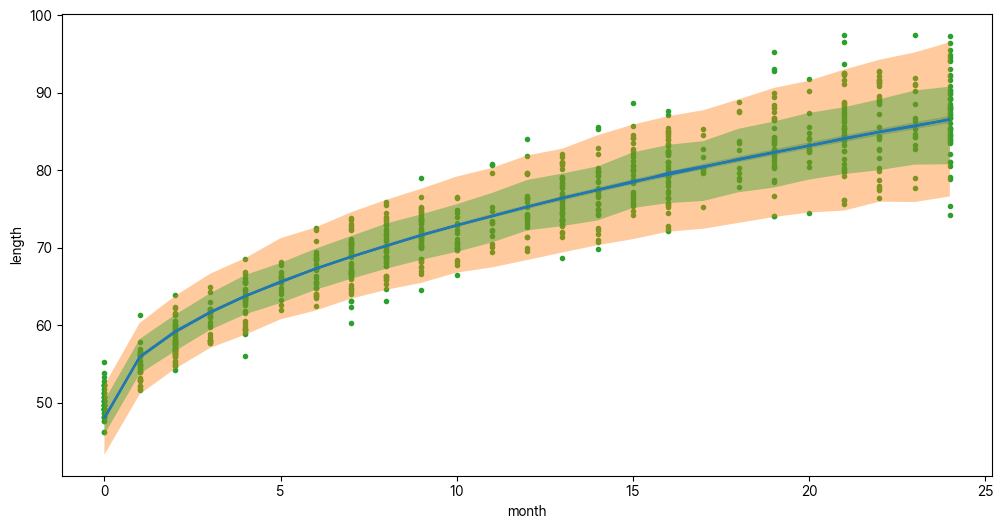

In [19]:
_, ax = plt.subplots(sharey=True, sharex='col', figsize=(12, 6))
bmb.interpret.plot_predictions(model_dis, idata_dis, 'month', ax=ax, )
bmb.interpret.plot_predictions(model_dis, idata_dis, 'month', pps=True, ax=ax, )
ax_ = bmb.interpret.plot_predictions(model_dis, idata_dis, 'month', pps=True, ax=ax, prob=0.65)

ax.plot(babies.month, babies.length, "C2.", zorder=-3)

In [20]:
model_dis.predict(idata_dis, kind='pps', data=pd.DataFrame({"month":[0.5]}))

In [21]:
idata_dis

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

In [22]:
ref = 52.5
y_ppc = idata_dis.posterior_predictive["length"].stack(sample=('chain', 'draw'))
y_ppc

<xarray.DataArray 'length' (length_obs: 1, sample: 4000)>
array([[52.9774199 , 53.94773458, 56.04183158, ..., 52.89019259,
        53.03291966, 50.91639504]])
Coordinates:
  * length_obs  (length_obs) int64 0
  * sample      (sample) object MultiIndex
  * chain       (sample) int64 0 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3 3
  * draw        (sample) int64 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

3992.860858942812

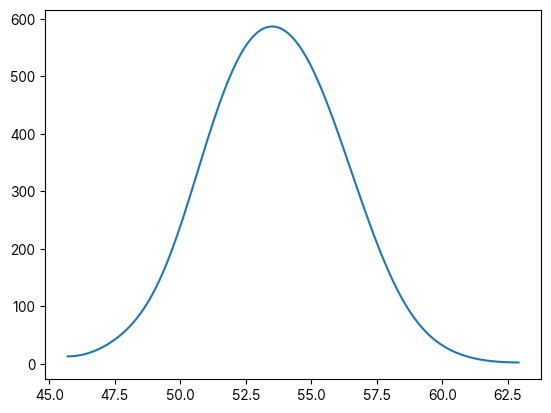

In [23]:
grid, pdf = az.stats.density_utils._kde_linear(y_ppc.values)
plt.plot(grid, pdf)
np.trapz(pdf, grid) 

0.9980929659619062

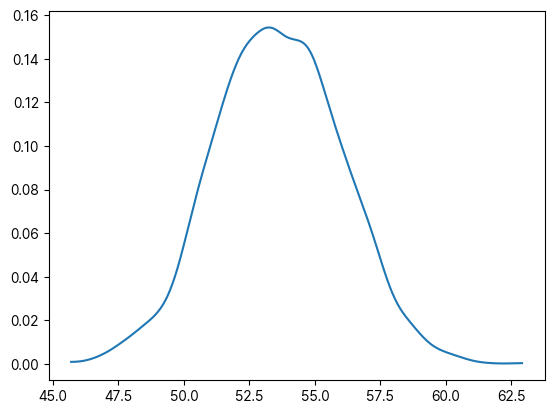

In [24]:
grid, pdf = az.kde(y_ppc.values)
plt.plot(grid, pdf)
np.trapz(pdf, grid) 

Categorical Predictors

In [25]:
penguins = pd.read_csv('../code/data/penguins.csv').dropna()
penguins

,species,island,bill_length,bill_depth,flipper_length,body_mass,sex,year
0,Adelie,Torgersen,3.91,1.87,18.1,3.750,male,2007
1,Adelie,Torgersen,3.95,1.74,18.6,3.800,female,2007
2,Adelie,Torgersen,4.03,1.80,19.5,3.250,female,2007
4,Adelie,Torgersen,3.67,1.93,19.3,3.450,female,2007
5,Adelie,Torgersen,3.93,2.06,19.0,3.650,male,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,5.58,1.98,20.7,4.000,male,2009
340,Chinstrap,Dream,4.35,1.81,20.2,3.400,female,2009
341,Chinstrap,Dream,4.96,1.82,19.3,3.775,male,2009
342,Chinstrap,Dream,5.08,1.90,21.0,4.100,male,2009


In [26]:
unique_categories = np.unique(penguins.species)
unique_categories

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [27]:
category_color_map = {cat:f"C{i}" for i, cat in enumerate(unique_categories)}
category_color_map

{'Adelie': 'C0', 'Chinstrap': 'C1', 'Gentoo': 'C2'}

In [28]:
colors = [category_color_map[cat] for cat in penguins.species]
colors

['C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',

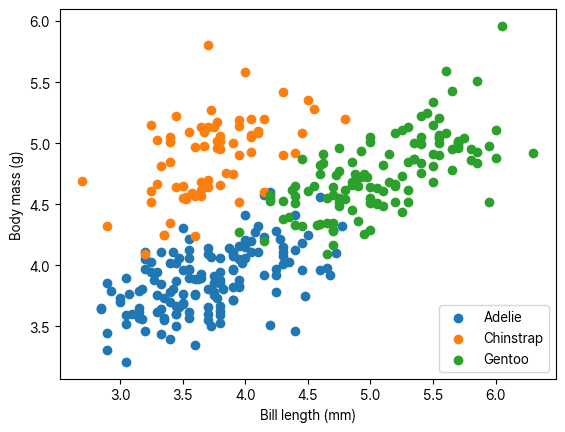

In [29]:
for cat in unique_categories:
    category_data = penguins[penguins.species == cat]
    plt.scatter(category_data.body_mass, 
                category_data.bill_length, 
                c=category_color_map[cat], 
                label=cat)
    
plt.ylabel('Body mass (g)')
plt.xlabel('Bill length (mm)')
plt.legend(labels=unique_categories, loc='lower right')

In [30]:
model_p = bmb.Model('body_mass ~ bill_length + species', 
                    data=penguins)
idata_p = model_p.fit()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [body_mass_sigma, Intercept, bill_length, species]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [31]:
model_p

       Formula: body_mass ~ bill_length + species
        Family: gaussian
          Link: mu = identity
  Observations: 333
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 4.2071, sigma: 16.4185)
            bill_length ~ Normal(mu: 0.0, sigma: 3.681)
            species ~ Normal(mu: [0. 0.], sigma: [4.9862 4.1943])
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.804)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

In [32]:
idata_p

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

Text(<xarray.DataArray 'species' ()>
array(0.59915848)
Coordinates:
    species_dim  <U9 'Gentoo', 1.7, '0.60')

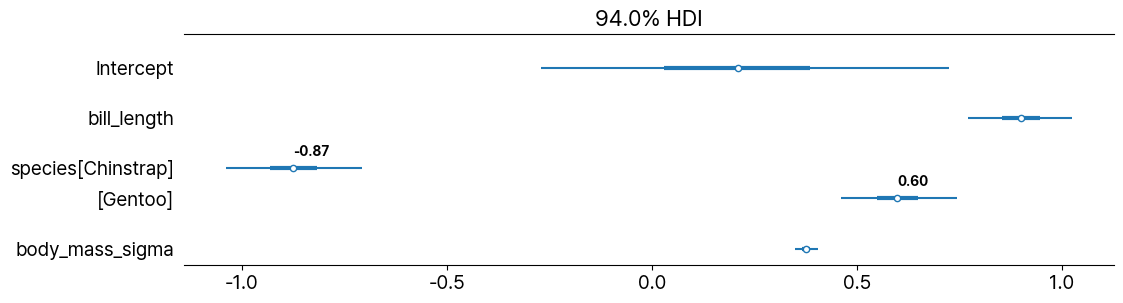

In [33]:
ax = az.plot_forest(idata_p, combined=True, figsize=(12, 3))
mean_chinstrap = idata_p.posterior['species'].sel(species_dim='Chinstrap').mean()
mean_gentoo = idata_p.posterior['species'].sel(species_dim='Gentoo').mean()
ax[0].annotate(f'{mean_chinstrap.item():.2f}', (mean_chinstrap, 2.5), weight='bold')
ax[0].annotate(f'{mean_gentoo.item():.2f}', (mean_gentoo, 1.7), weight='bold')

(<Figure size 1100x400 with 1 Axes>,
 array([<Axes: xlabel='bill_length', ylabel='body_mass'>], dtype=object))

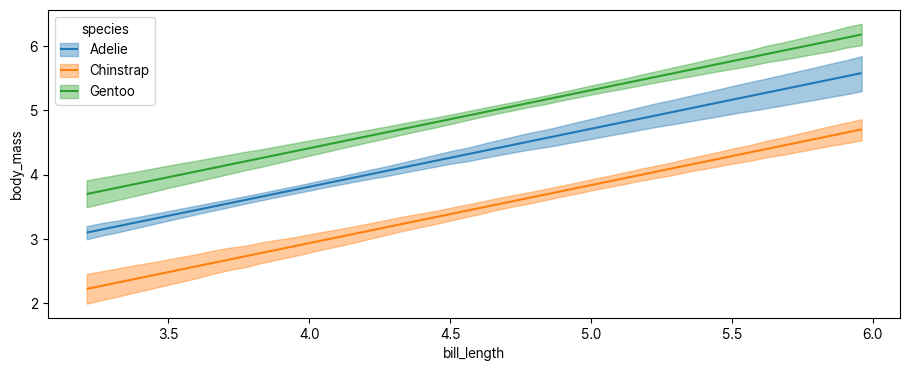

In [34]:
bmb.interpret.plot_predictions(model_p, idata_p, 
                               ["bill_length", "species"],
                               fig_kwargs={"figsize":(11, 4)})

Interactions

In [35]:
model_int = bmb.Model('body_mass ~ bill_depth + bill_length + bill_depth:bill_length', data=penguins)
idata_int = model_int.fit(random_seed=123)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [body_mass_sigma, Intercept, bill_depth, bill_length, bill_depth:bill_length]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


In [36]:
model_no_int = bmb.Model('body_mass ~ bill_depth + bill_length', data=penguins)
idata_no_int = model_no_int.fit()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [body_mass_sigma, Intercept, bill_depth, bill_length]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


(<Figure size 1200x450 with 2 Axes>,
 array([<Axes: xlabel='bill_depth', ylabel='body_mass'>], dtype=object))

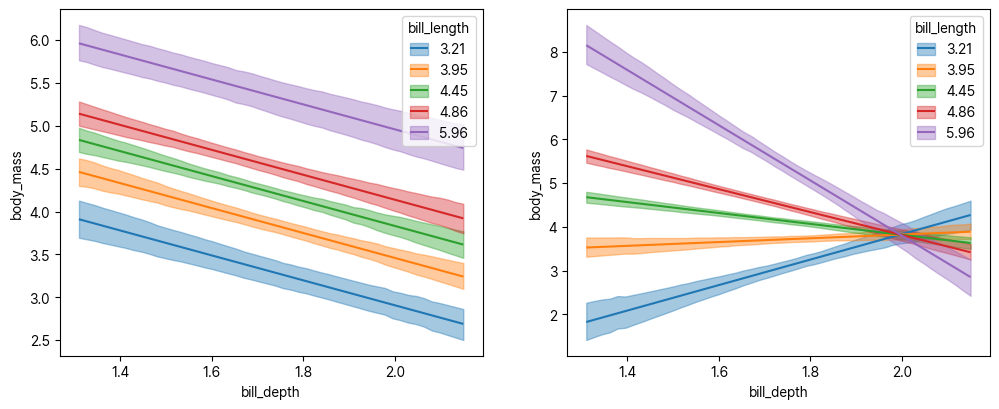

In [37]:
_, axes = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={'hspace': 0.1})

bmb.interpret.plot_predictions(model_no_int, idata_no_int, 
                               ["bill_depth", "bill_length"],
                               ax=axes[0],)
bmb.interpret.plot_predictions(model_int, idata_int, 
                               ['bill_depth', 'bill_length'],
                               ax=axes[1])

(<Figure size 640x480 with 1 Axes>,
 array([<Axes: xlabel='bill_length', ylabel='body_mass'>], dtype=object))

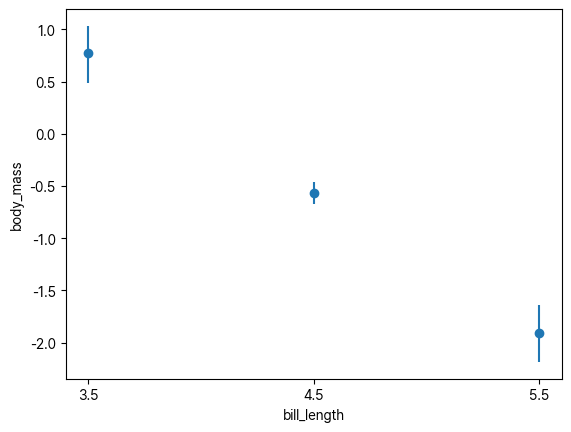

In [38]:
bmb.interpret.plot_comparisons(model_int, idata_int, 
                               contrast={'bill_depth':[1.4, 1.8]},
                               conditional={'bill_length':[3.5, 4.5, 5.5]})

(<Figure size 640x480 with 1 Axes>,
 array([<Axes: xlabel='bill_length', ylabel='body_mass'>], dtype=object))

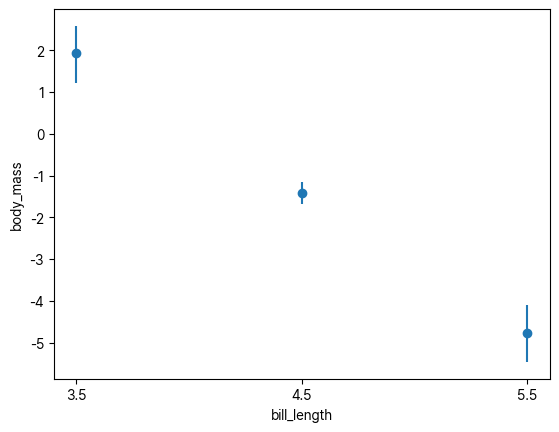

In [39]:
bmb.interpret.plot_slopes(model_int, idata_int, 
                          wrt={'bill_depth':1.8},
                          conditional={'bill_length':[3.5, 4.5, 5.5]})

Variable selection 

In [40]:
import kulprit as kpt

In [41]:
body = pd.read_csv('../code/data/body_fat.csv')
body

,siri,age,weight,height,abdomen,thigh,wrist
0,12.3,23,70.1,172,85.2,59.0,17.1
1,6.1,22,78.8,184,83.0,58.7,18.2
2,25.3,22,70.0,168,87.9,59.6,16.6
3,10.4,26,84.0,184,86.4,60.1,18.2
4,28.7,24,83.8,181,100.0,63.2,17.7
...,...,...,...,...,...,...,...
246,11.0,70,61.0,170,83.6,49.6,18.5
247,33.6,72,91.4,177,105.0,59.6,20.1
248,29.3,72,84.9,168,111.5,60.3,18.0
249,26.0,72,86.7,179,101.3,56.0,19.8


In [42]:
model = bmb.Model('siri ~ age + weight + height + abdomen + thigh + wrist', body)
model

       Formula: siri ~ age + weight + height + abdomen + thigh + wrist
        Family: gaussian
          Link: mu = identity
  Observations: 251
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 19.0869, sigma: 777.7268)
            age ~ Normal(mu: 0.0, sigma: 1.648)
            weight ~ Normal(mu: 0.0, sigma: 1.6936)
            height ~ Normal(mu: 0.0, sigma: 3.1202)
            abdomen ~ Normal(mu: 0.0, sigma: 2.0371)
            thigh ~ Normal(mu: 0.0, sigma: 4.2)
            wrist ~ Normal(mu: 0.0, sigma: 22.7762)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 8.307)

In [43]:
idata = model.fit(idata_kwargs={'log_likelihood': True}, random_seed=123)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [siri_sigma, Intercept, age, weight, height, abdomen, thigh, wrist]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


In [44]:
ppi = kpt.ProjectionPredictive(model, idata)
ppi.search()
ppi

  0 siri ~ 1
  1 siri ~ abdomen
  2 siri ~ abdomen + weight
  3 siri ~ abdomen + weight + wrist
  4 siri ~ abdomen + weight + wrist + age
  5 siri ~ abdomen + weight + wrist + age + thigh
  6 siri ~ abdomen + weight + wrist + age + thigh + height

In [45]:
submodel = ppi.project(3)
submodel

siri ~ abdomen + weight + wrist

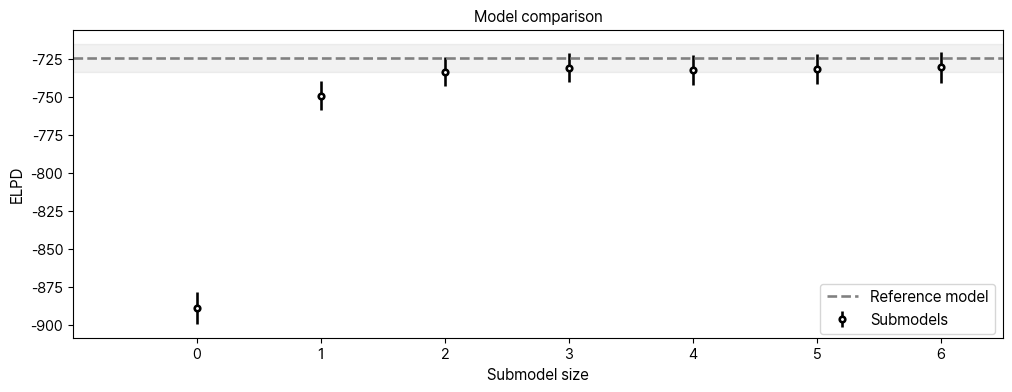

In [46]:
cmp, ax = ppi.plot_compare(plot=True, figsize=(12, 4))

array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'abdomen'}>,
        <Axes: title={'center': 'weight'}>],
       [<Axes: title={'center': 'wrist'}>,
        <Axes: title={'center': 'siri_sigma'}>, <Axes: >]], dtype=object)

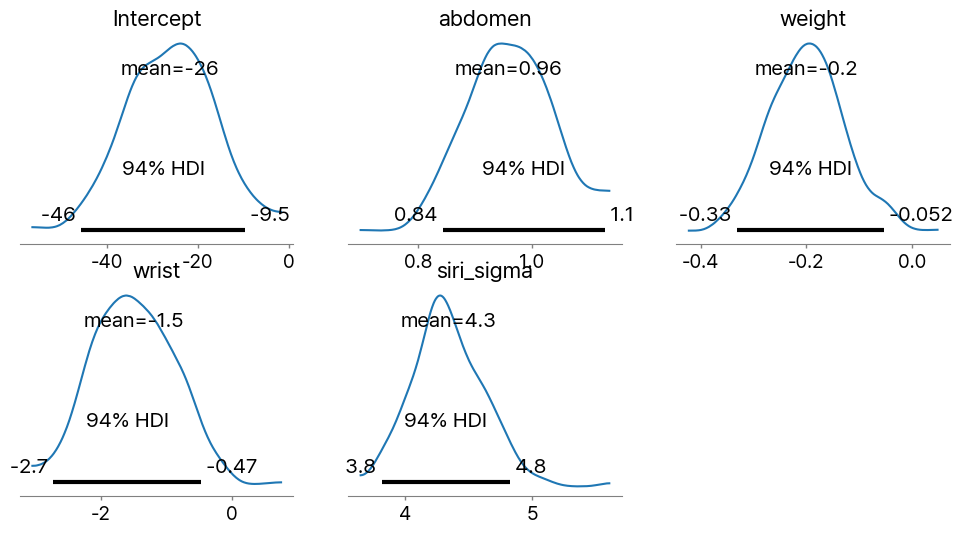

In [47]:
az.plot_posterior(submodel.idata, figsize=(12, 6))

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

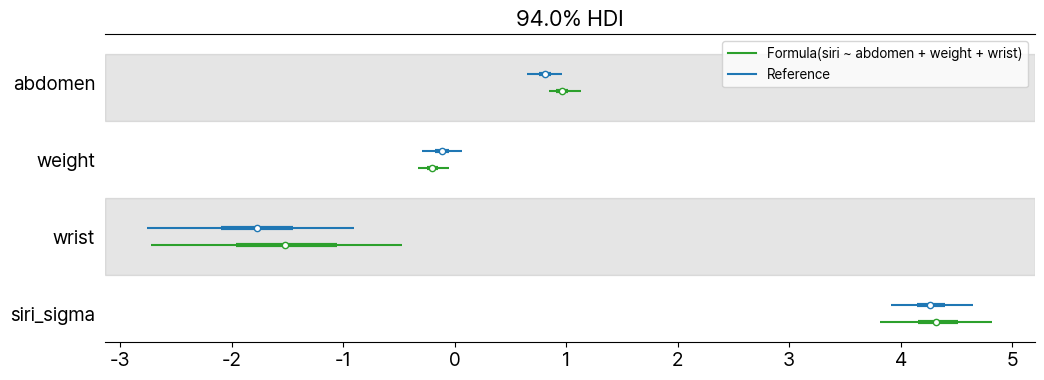

In [48]:
ppi.plot_densities(var_names=['~Intercept', '~age', '~height', '~thigh'],
                   submodels=[3],
                   kind='forest',
                   figsize=(12, 4),
                   plot_kwargs={"colors": ["C0", "C2"]}
                   )